In [1]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# 테스트용 초기 state 만들기
from state import TravelState, UserInput, Place, make_initial_state
from constants.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [4]:
# [노드] validate_input
# 사용자 입력 -> 좌표 변환, 식사 시간 계산 (전처리)
from nodes.validate_input import validate_input

validate_result = validate_input(initial_state)
# print("validate_input 결과:", validate_result)


In [5]:
# [노드] fetch_candidates
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.fetch_candidates import fetch_candidates

candidates_result = await fetch_candidates(validate_result)
# print("candidates_result 결과:", candidates_result)


In [6]:
from nodes.filter_candidates import filter_candidates

filter_result = filter_candidates(candidates_result)
# print("filter_result 결과:", filter_result)

In [11]:
from nodes.enrich_candidates import enrich_candidates

test_state = {
    "filtered_candidates": filter_result["filtered_candidates"],
    "user_input": mock_user_input,
    "warnings": [],
}

enrich_result = await enrich_candidates(test_state)

print(f"⚠️ warnings: {enrich_result['warnings']}")
print(f"✅ step: {enrich_result['step']}")
print(f"📦 보강된 장소 수: {len(enrich_result['filtered_candidates'])}")
print(f"📊 scored_candidates 수: {len(enrich_result['scored_candidates'])}")
print(f"🏆 shortlist 수: {len(enrich_result['shortlist'])}")

print("\n=== shortlist 점수 순위 ===")
for i, s in enumerate(enrich_result["shortlist"], 1):
    p = s["place"]
    print(f"""
{i}위. {p['name']}
  분위기: {p.get('atmosphere')}
  추천대상: {p.get('best_for')}
  재방문의사: {p.get('revisit_intent')}
  한줄요약: {p.get('summary')}
  mood_score: {s['mood_score']}
  activity_score: {s['activity_score']}
  party_fit_score: {s['party_fit_score']}
  total_score: {s['total_score']}
""")

⚠️ warnings: []
✅ step: enriched
📦 보강된 장소 수: 50
📊 scored_candidates 수: 50
🏆 shortlist 수: 30

=== shortlist 점수 순위 ===

1위. 블랙업커피 해운대점
  분위기: ['활기찬', '힐링']
  추천대상: ['혼자', '가족']
  재방문의사: medium
  한줄요약: 부산 블루리본 맛집으로 유명.
  mood_score: 0.6666666666666666
  activity_score: 0.14285714285714285
  party_fit_score: 0.7
  total_score: 0.4638


2위. 제스터
  분위기: ['이색', '힐링']
  추천대상: ['친구', '가족']
  재방문의사: medium
  한줄요약: 치즈 그라인더와 특별한 맛.
  mood_score: 0.6666666666666666
  activity_score: 0.14285714285714285
  party_fit_score: 0.7
  total_score: 0.4638


3위. 플레이포인트랩 해운대 블루오션스테이션점
  분위기: ['활기찬', '이색']
  추천대상: ['친구', '가족']
  재방문의사: medium
  한줄요약: 어드벤처 테마의 플레이랩.
  mood_score: 0.6666666666666666
  activity_score: 0.14285714285714285
  party_fit_score: 0.7
  total_score: 0.4638


4위. 왕미미오락실
  분위기: ['활기찬', '이색']
  추천대상: ['친구', '가족']
  재방문의사: low
  한줄요약: 해운대의 대형 오락실.
  mood_score: 0.6666666666666666
  activity_score: 0.0
  party_fit_score: 0.7
  total_score: 0.4067


5위. 민트플레이 해운대2호점
  분위기: ['활기찬', '이색']
  추천대상:

In [8]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("validate_input", validate_input)
graph_builder.add_node("fetch_candidates", fetch_candidates)
graph_builder.add_node("filter_candidates", filter_candidates)
graph_builder.add_node("enrich_candidates", enrich_candidates)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "validate_input")
graph_builder.add_edge("validate_input", "fetch_candidates")
graph_builder.add_edge("fetch_candidates", "filter_candidates")
graph_builder.add_edge("filter_candidates", "enrich_candidates")
graph_builder.add_edge("enrich_candidates", END)

graph = graph_builder.compile()

In [9]:
# 그래프 실행
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print(f"✅ step: {state_v1['step']}\n")

for p in filter_result["filtered_candidates"][:5]:
    print(
        f"  [{p.get('category_group_code', '기타')}] {p['name']} - "
        f"{p.get('road_address_name') or p.get('address_name', '')}"
    )

📍 위치: 해운대역
📌 좌표: (35.1636479638612, 129.158897240251)
🔍 Kakao raw 후보: 275개
⚠️  warnings: []
❌ errors: []
✅ step: enriched

  [FD6] 강릉송정해변막국수 부산분점 - 부산 해운대구 좌동순환로446번길 15-6
  [FD6] 해운대 바다김밥 - 부산 해운대구 중동1로 33-1
  [FD6] 바다마루전복죽 - 부산 해운대구 달맞이길62번길 7
  [FD6] 온천떡집 - 부산 해운대구 구남로41번길 33
  [FD6] 해목 - 부산 해운대구 구남로24번길 8


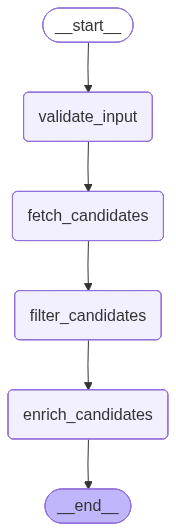

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))